In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load master dataset
df = pd.read_csv('../data/master_dataset.csv')

print(f"Shape: {df.shape}")
df.head()

Shape: (500, 15)


,student_id,age,gender,department,year,attendance_pct,total_absences,avg_quiz,avg_exam,final_grade,lms_logins,resources_accessed,forum_posts,assignments_submitted,risk_level
0,S0001,23,Other,EE,1,80.083333,8,63.775,70.875,67.325,11,35,5,12,Low
1,S0002,20,M,CS,1,84.700000,6,61.775,68.650,65.200,7,8,2,13,Low
2,S0003,21,M,CE,1,77.183333,11,65.175,72.400,68.775,18,42,0,14,Low
3,S0004,23,Other,CE,4,68.250000,17,52.350,58.175,55.275,29,5,17,8,Medium
4,S0005,19,M,IT,1,69.000000,16,64.600,71.775,68.175,26,7,4,13,Low


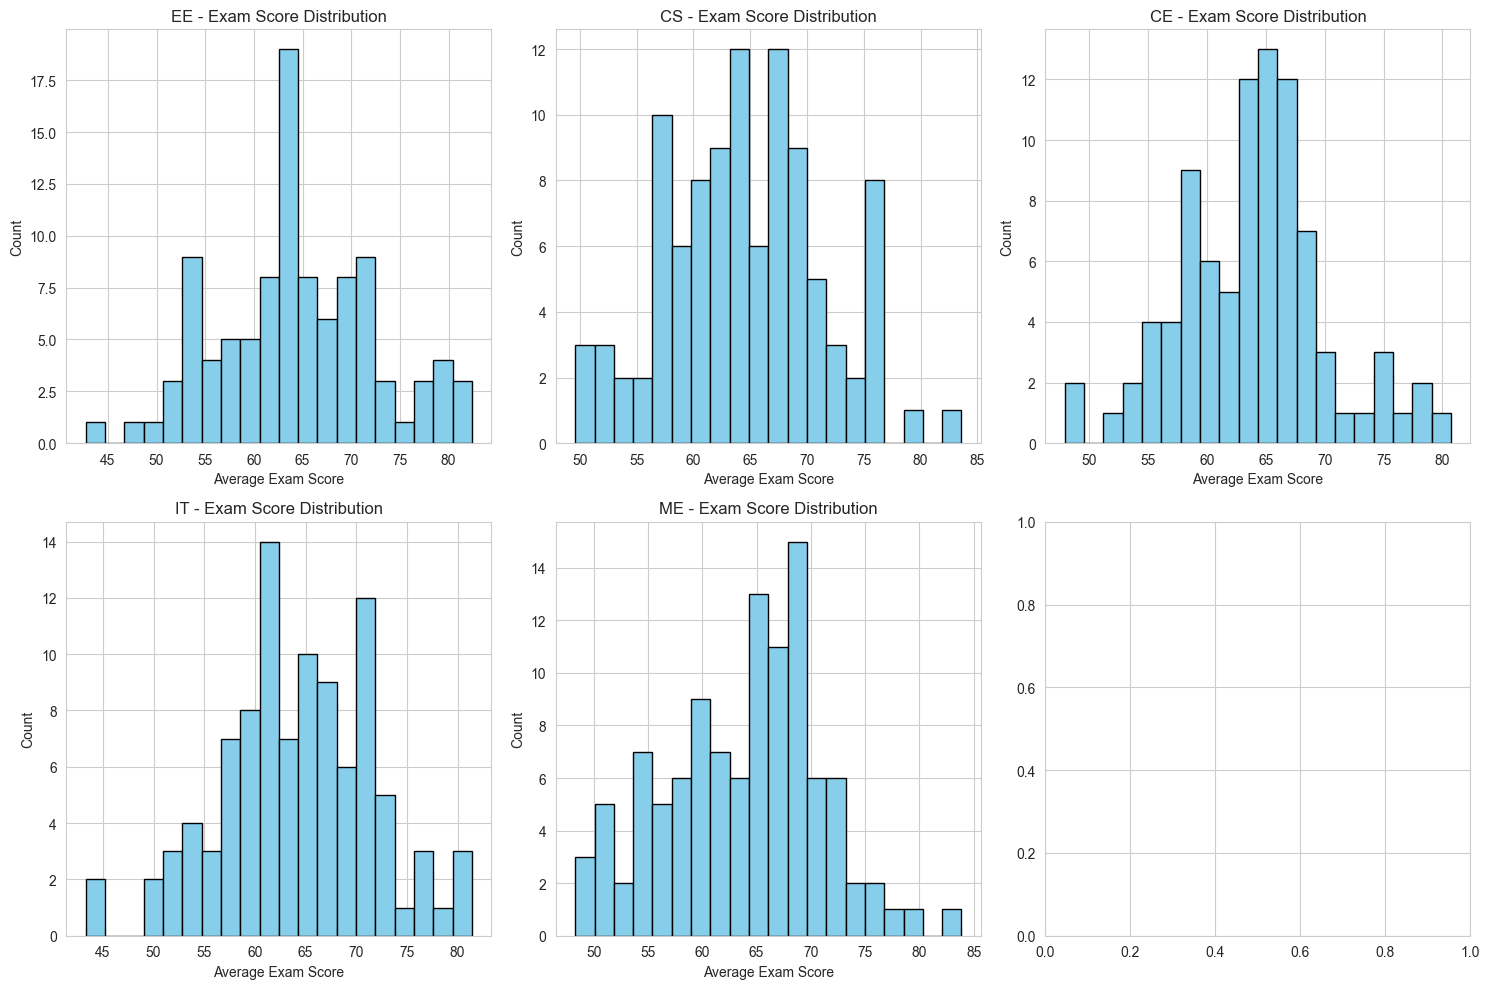

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Distribution plots
for idx, dept in enumerate(df['department'].unique()):
    ax = axes[idx // 3, idx % 3]
    dept_data = df[df['department'] == dept]['avg_exam']
    ax.hist(dept_data, bins=20, color='skyblue', edgecolor='black')
    ax.set_title(f'{dept} - Exam Score Distribution')
    ax.set_xlabel('Average Exam Score')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('../docs/exam_dist_by_dept.png', dpi=150)
plt.show()

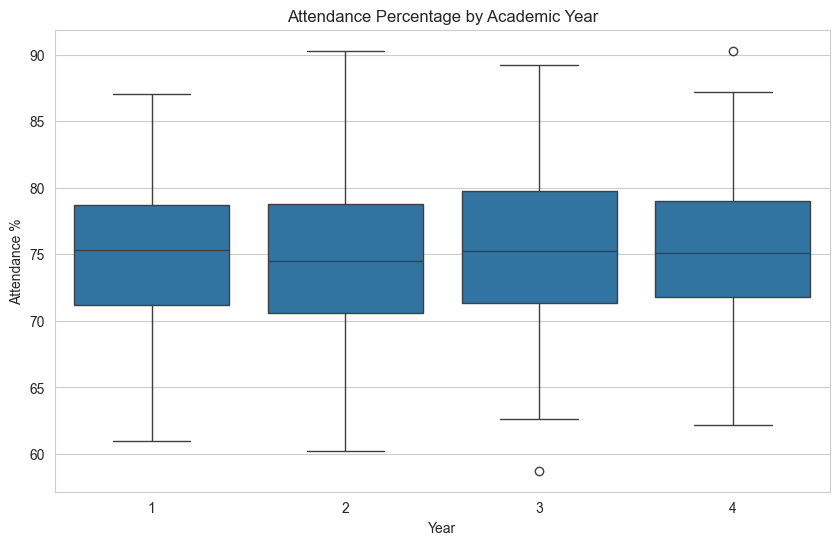

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='year', y='attendance_pct')
plt.title('Attendance Percentage by Academic Year')
plt.xlabel('Year')
plt.ylabel('Attendance %')
plt.savefig('../docs/attendance_by_year.png', dpi=150)
plt.show()

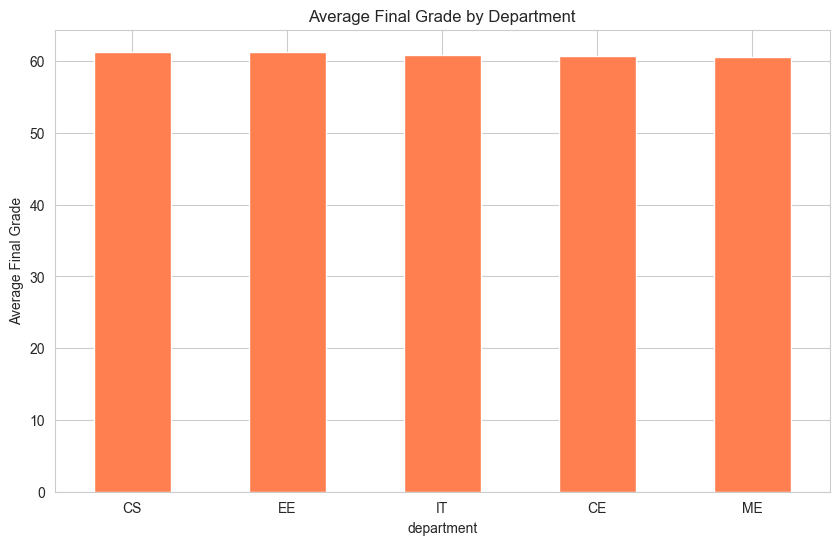

In [12]:
plt.figure(figsize=(10, 6))
dept_grades = df.groupby('department')['final_grade'].mean().sort_values(ascending=False)
dept_grades.plot(kind='bar', color='coral')
plt.title('Average Final Grade by Department')
plt.ylabel('Average Final Grade')
plt.xticks(rotation=0)
plt.savefig('../docs/avg_grade_by_dept.png', dpi=150)
plt.show()

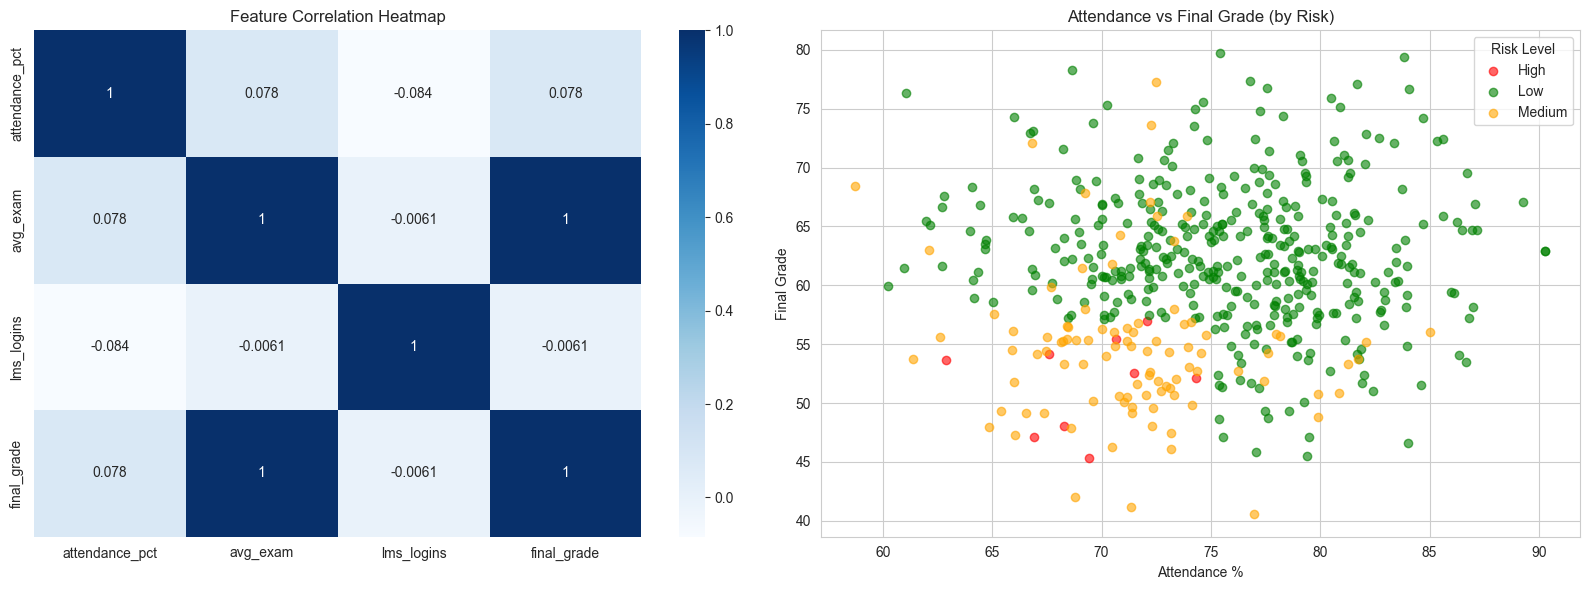

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: heatmap
corr_cols = ['attendance_pct', 'avg_exam', 'lms_logins', 'final_grade']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='Blues', ax=axes[0])
axes[0].set_title('Feature Correlation Heatmap')

# Right: scatter with risk color
colors = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}
for risk, grp in df.groupby('risk_level'):
    axes[1].scatter(grp['attendance_pct'], grp['final_grade'],
                    c=colors[risk], label=risk, alpha=0.6)
axes[1].set_xlabel('Attendance %')
axes[1].set_ylabel('Final Grade')
axes[1].legend(title='Risk Level')
axes[1].set_title('Attendance vs Final Grade (by Risk)')

plt.tight_layout()
plt.savefig('../docs/eda_charts.png', dpi=150)
plt.show()

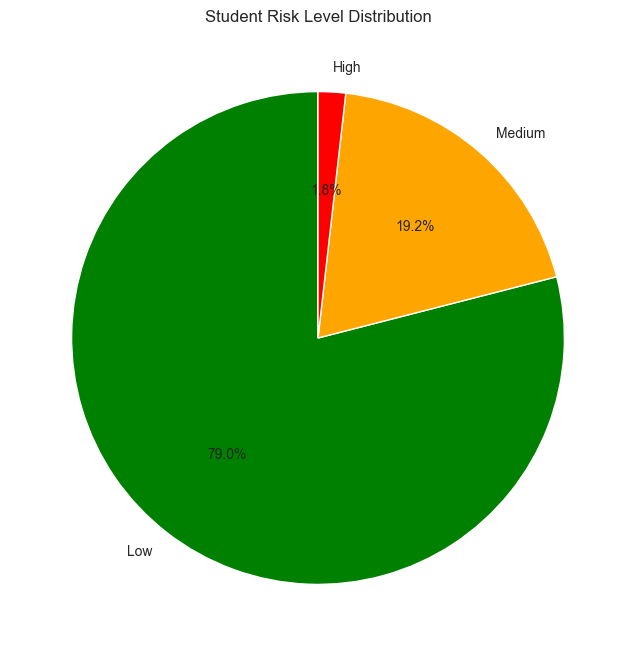

In [15]:
plt.figure(figsize=(8, 8))
risk_counts = df['risk_level'].value_counts()
colors_pie = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
        colors=[colors_pie[r] for r in risk_counts.index],
        startangle=90)
plt.title('Student Risk Level Distribution')
plt.savefig('../docs/risk_distribution.png', dpi=150)
plt.show()

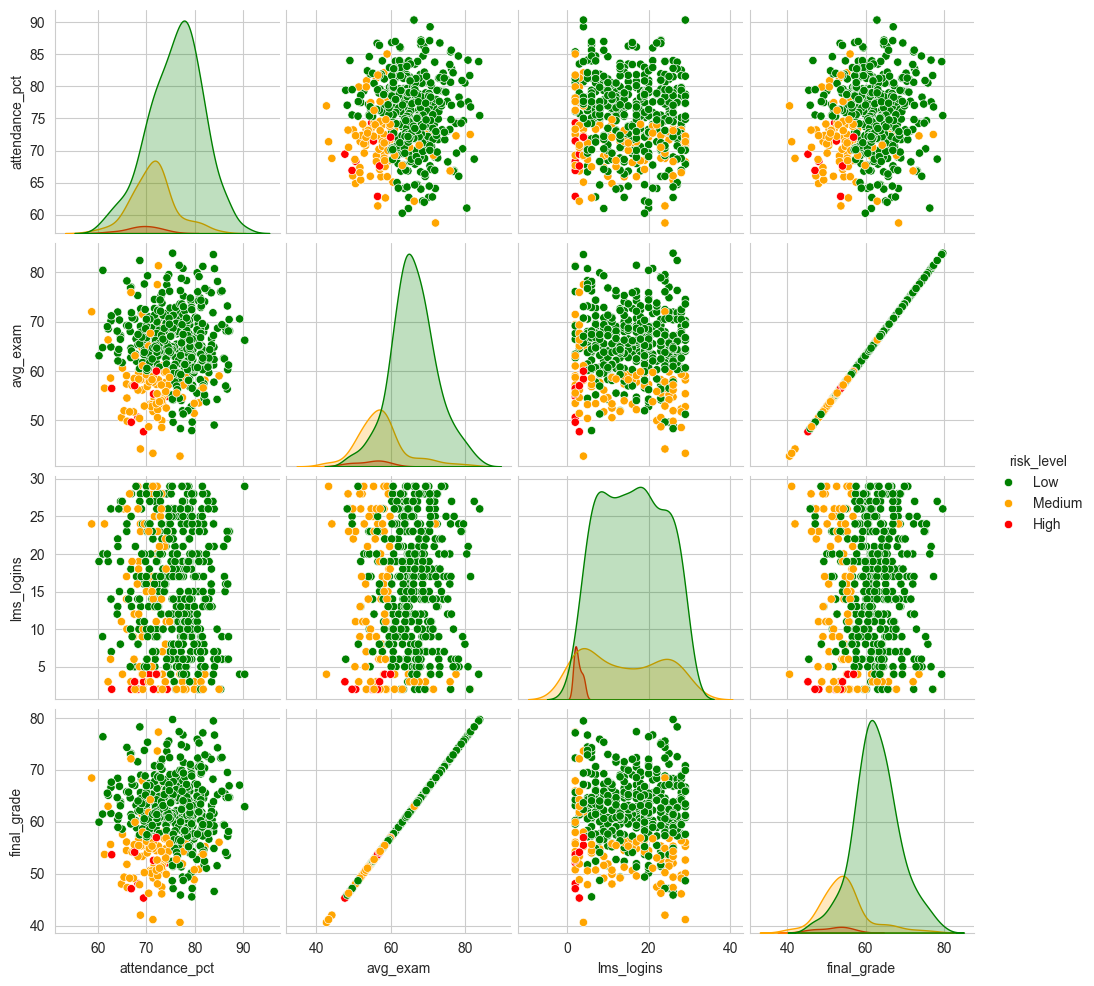

In [16]:
pair_cols = ['attendance_pct', 'avg_exam', 'lms_logins', 'final_grade']
sns.pairplot(df[pair_cols + ['risk_level']], hue='risk_level',
             palette={'Low': 'green', 'Medium': 'orange', 'High': 'red'})
plt.savefig('../docs/pairplot.png', dpi=150)
plt.show()